In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns



### Driving questions
    - What percentage of delays are due to security issues?
    - How much time is the average security delay? 


### Phase 1: Load and Initial Reconnaissance

In [49]:

DATA_PATH = "data/bts_all.parquet"  

df = pd.read_parquet(DATA_PATH)
df.head()


,FlightDate,Reporting_Airline,Tail_Number,Origin,Dest,CRSDepTime,DepDelay,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2020-01-17,B6,N661JB,PBI,BDL,1940,-14.0,15.0,1941.0,2212.0,6.0,2229,-11.0,1133.0,NaN,NaN,NaN,NaN,NaN
1,2020-01-18,B6,N584JB,PBI,BDL,1940,-14.0,14.0,1940.0,2207.0,13.0,2229,-9.0,1133.0,NaN,NaN,NaN,NaN,NaN
2,2020-01-19,B6,N662JB,PBI,BDL,1940,7.0,11.0,1958.0,2217.0,6.0,2229,-6.0,1133.0,NaN,NaN,NaN,NaN,NaN
3,2020-01-20,B6,N784JB,PBI,BDL,1940,-7.0,27.0,2000.0,2220.0,13.0,2229,4.0,1133.0,NaN,NaN,NaN,NaN,NaN
4,2020-01-21,B6,N784JB,PBI,BDL,1940,12.0,10.0,2002.0,2229.0,6.0,2229,6.0,1133.0,NaN,NaN,NaN,NaN,NaN


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35417940 entries, 0 to 35417939
Data columns (total 19 columns):
 #   Column             Dtype  
---  ------             -----  
 0   FlightDate         object 
 1   Reporting_Airline  object 
 2   Tail_Number        object 
 3   Origin             object 
 4   Dest               object 
 5   CRSDepTime         int64  
 6   DepDelay           float64
 7   TaxiOut            float64
 8   WheelsOff          float64
 9   WheelsOn           float64
 10  TaxiIn             float64
 11  CRSArrTime         int64  
 12  ArrDelay           float64
 13  Distance           float64
 14  CarrierDelay       float64
 15  WeatherDelay       float64
 16  NASDelay           float64
 17  SecurityDelay      float64
 18  LateAircraftDelay  float64
dtypes: float64(12), int64(2), object(5)
memory usage: 5.0+ GB


In [51]:
df.shape

(35417940, 19)

In [52]:
# Initial Look at security delay
df["SecurityDelay"].describe()


count    6.574036e+06
mean     1.465667e-01
std      3.633254e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.460000e+03
Name: SecurityDelay, dtype: float64

Given the zeroes in the IQR and the very low mean, we can assume security delays are rare.  Given this, we'll focus on non-zero sercurity delays to analyze their characteristics when they do occur. 

In [53]:

print("Unique origin airports:", df["Origin"].nunique())
print("Unique destination airports:", df["Dest"].nunique())


Unique origin airports: 383
Unique destination airports: 384


### Phase 2: Data Quality

In [54]:
#Ensure security delays are positive values
negative_security = df[df["SecurityDelay"] < 0]
print("Negative SECURITY_DELAY rows:", len(negative_security))




Negative SECURITY_DELAY rows: 0


In [55]:
#Check for NaN
na_counts = df.isna().sum().sort_values(ascending=False)
na_counts


SecurityDelay        28843904
NASDelay             28843904
WeatherDelay         28843904
CarrierDelay         28843904
LateAircraftDelay    28843904
ArrDelay               900851
WheelsOn               825014
TaxiIn                 825014
WheelsOff              813153
TaxiOut                813153
DepDelay               799566
Tail_Number            248493
FlightDate                  0
Reporting_Airline           0
CRSDepTime                  0
Dest                        0
Origin                      0
Distance                    0
CRSArrTime                  0
dtype: int64

Key columns (FlightDate, Des, Origin,etc.) have no missing values. Missing values are expected in other columns as they are not always reported.

In [56]:
#Check for outliers, but only evaluate non-zero security delays
sec_pos = df.loc[df["SecurityDelay"] > 0, "SecurityDelay"]

Q1 = sec_pos.quantile(0.25)
Q3 = sec_pos.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print("IQR:")
print(Q1, Q3, IQR, upper_bound)
outliers = len(df[df["SecurityDelay"] > upper_bound]["SecurityDelay"])
print("Outliers",outliers)
print("Outlier Percent:",outliers/len(sec_pos)*100)


IQR:
10.0 30.0 20.0 60.0
Outliers 2860
Outlier Percent: 8.016818500350386


Outlier conlusion:  Only 8% of the sercurity delays are outside the upper bound. Outliers are not a concern for this analysis. 

### Phase 3:  Cleaning Decisions & Implementation

In [57]:
#Turn flight date into a datetime
df["FlightDate"] = pd.to_datetime(df["FlightDate"], errors="coerce")
df["FlightDate"].head()


0   2020-01-17
1   2020-01-18
2   2020-01-19
3   2020-01-20
4   2020-01-21
Name: FlightDate, dtype: datetime64[ns]

### Phase 4:  Statistical EDA

In [58]:
#Frequency of Sercurity Delays
any_sec_delay = df["SecurityDelay"] > 0

avg_sec_delay_all = df["SecurityDelay"].mean()
avg_sec_delay_pos = df.loc[any_sec_delay, "SecurityDelay"].mean()

print(f"Fraction of flights with any security delay: {sec_delay_rate:.4%}")
print(f"Average security delay given SECURITY_DELAY > 0: {avg_sec_delay_pos:.2f} minutes")


Fraction of flights with any security delay: 0.1007%
Average security delay given SECURITY_DELAY > 0: 27.01 minutes


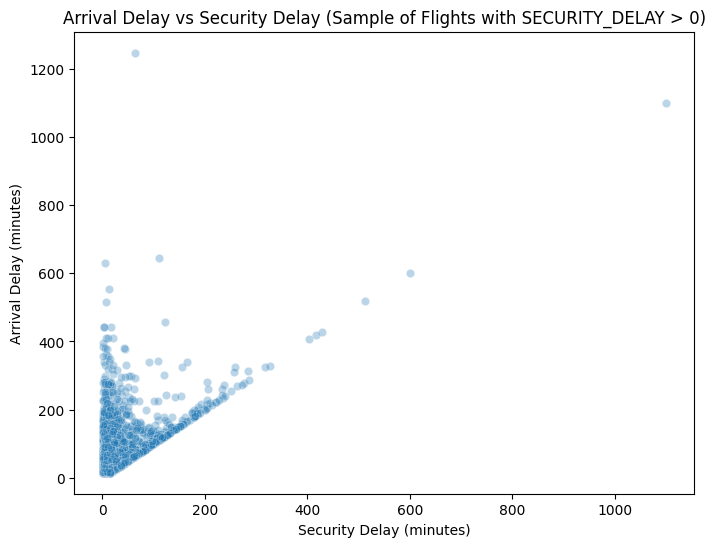

In [59]:
plt.figure(figsize=(8, 6))
sample = df.loc[any_sec_delay, ["ArrDelay", "SecurityDelay"]].sample(
    min(5000, any_sec_delay.sum()),
    random_state=42
)

sns.scatterplot(data=sample, x="SecurityDelay", y="ArrDelay", alpha=0.3)
plt.title("Arrival Delay vs Security Delay (Sample of Flights with SECURITY_DELAY > 0)")
plt.xlabel("Security Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")
plt.show()


The above scatter plot reveals an expected pattern:
- No total delays below the security delay time (total delay must be >= any contributor)
- With increasing security delay times, the total delay is more likely to be equal to security delay.

Which airlines have the highest rate of security delay?

In [60]:
carrier_sec = df.groupby("Reporting_Airline").agg(
    flights=("FlightDate", "count"),
    sec_delay_count=("SecurityDelay", lambda x: (x > 0).sum()),
    avg_sec_delay_positive=("SecurityDelay", lambda x: x[x > 0].mean())
).assign(
    pct_flights_with_sec=lambda x: x["sec_delay_count"] / x["flights"]
).sort_values("pct_flights_with_sec", ascending=False)

carrier_sec.head(10)


,flights,sec_delay_count,avg_sec_delay_positive,pct_flights_with_sec
Reporting_Airline,,,,
NK,1208418,6691,21.670004,0.005537
AS,1187102,3186,23.524482,0.002684
G4,645833,1453,31.973159,0.002250
B6,1271272,2375,26.360842,0.001868
HA,381281,611,21.250409,0.001602
OH,1200206,1896,18.477848,0.001580
AA,4674342,7249,22.899296,0.001551
WN,7004353,6643,29.543429,0.000948
MQ,1392600,1198,21.459098,0.000860


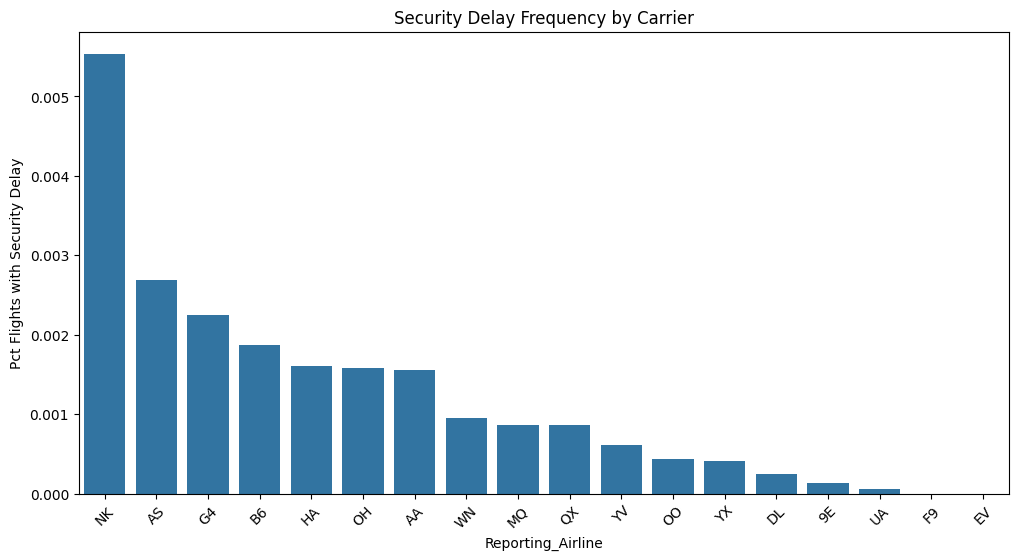

In [61]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=carrier_sec.reset_index(),
    x="Reporting_Airline",
    y="pct_flights_with_sec"
)
plt.xticks(rotation=45)
plt.title("Security Delay Frequency by Carrier")
plt.ylabel("Pct Flights with Security Delay")
plt.show()


Spirit Airlines has the highhest delay, but the overall percentage values are very low (<1%).  We can conclude that security delays are not a significant factor in choosing an airline.

However, the average security delay time of 27 minutes begs the question:  Hoe does this length of time compare to other delay types? 

In [62]:
delay_cols = [
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay"
]

df_delay = df[delay_cols]


In [63]:
pos_delay_stats = df_delay[df_delay > 0].describe()
pos_delay_stats


,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
count,3.705331e+06,395687.000000,3.146234e+06,35675.000000,3.200278e+06
mean,4.531588e+01,69.560979,2.683355e+01,27.008690,5.406393e+01
std,9.591257e+01,117.774587,4.112338e+01,41.316767,7.563053e+01
min,1.000000e+00,1.000000,1.000000e+00,1.000000,1.000000e+00
25%,9.000000e+00,16.000000,8.000000e+00,10.000000,1.600000e+01
50%,2.000000e+01,34.000000,1.700000e+01,18.000000,3.100000e+01
75%,4.400000e+01,77.000000,3.000000e+01,30.000000,6.500000e+01
max,3.957000e+03,2363.000000,2.700000e+03,1460.000000,3.581000e+03


Overall, when security delays do happen, they are shorter on average that other delay types, with the exception of NAS delays.

### Phase 5 Feature Engineering

N/A For this question

### Phase 6: Save and Document
Overall, security-related days were a minimal contributor to overall delays.
